# **Les tests d'hypothèses**

## **Contexte:**

Après avoir découvert les *statistiques descriptives*, qui permettent de **résumer et observer les données**, on peut aller plus loin avec les *tests d’hypothèses*. Ceux-ci répondent à une question clé : **l’effet ou la différence observée est-il réel, ou simplement dû au hasard ?** 

Pour le comprendre, il faut distinguer la *population*, c’est-à-dire l’ensemble complet des individus ou éléments que l’on voudrait étudier, et *l’échantillon*, qui en est un sous-ensemble accessible et sur lequel on fait des mesures. Comme il est souvent impossible d’analyser toute la population, les tests d’hypothèses permettent, à partir d’un échantillon, d’estimer si les résultats peuvent être généralisés à l’ensemble. En pratique, on compare les données observées à une situation de référence (l’hypothèse nulle) et on utilise les probabilités pour juger si l’écart observé est suffisamment significatif pour être pris au sérieux. Ainsi, on passe de la simple description des données à une véritable aide à la décision.

## Détails pratiques

Temps estimés :
- Parties 2/3 lois et théorèmes : 1/2 journée
- 4.2.1 > 4.2.3 : 1 journée
- 4.2.4 : 1/2 journée
- 5 enquête bonheur : 1/2 journée

Signification des émoticones :
- 🌞 : documentations importantes
- 🌚 : en complément
- (vide) : à vous de voir

# Import des librairies

In [2]:
# manipulation de dataframes
import pandas as pd 
pd.options.plotting.backend = "plotly"

🌞 https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

In [3]:
# réalisation des graphiques
import matplotlib.pyplot as plt

In [4]:
# réalisation des graphiques
import seaborn as sns

In [5]:
# tests d'hypothèses
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

In [6]:
# calculs scientifiques
import numpy as np

In [7]:
# fonction de répartition empirique
from statsmodels.distributions.empirical_distribution import ECDF

# Quelques lois intéressantes à connaitre en statistiques

Nous notons ici différentes lois intéressantes en statistiques. L'idée ici n'est pas de les connaitre toutes dans un premier temps, mais de savoir qu'elles existent. L'intérêt des lois pour nous aujourd'hui est de pouvoir comparer la distribution de nos variables à ces lois.

## Modèles discrets

Les variables aléatoires <b/>discrètes</b> prennent <b/>un nombre fini ou dénombrable</b> de valeurs distinctes.</br>
</br>

- Loi Uniforme : https://fr.wikipedia.org/wiki/Loi_uniforme_discr%C3%A8te</br>
La probabilité que la variable aléatoire X prenne chacune des valeurs de son support est identique, autrement dit, il y a équiprobabilité.</br>
</br>

- Loi de Bernouilli : https://fr.wikipedia.org/wiki/Loi_de_Bernoulli</br>
On considère une épreuve aléatoire à deux issues. L'une est considérée comme le succès, l'autre comme l'échec. C'est ce que l'on appelle une épreuve de Bernoulli.</br>
Par exemple, on lance un dé. On obtient 6, c'est le succès. On n'obtient pas 6, c'est l'échec.</br>
</br>

- Loi Binomiale : https://fr.wikipedia.org/wiki/Loi_binomiale</br>
On considère à nouveau une épreuve de Bernoulli : épreuve aléatoire à deux issues. L'une est considérée comme le succès, l'autre comme l'échec. Cette fois, on répète cette épreuve de manière identique et indépendante pour obtenir ce que l'on appelle un schéma de Bernoulli. </br>
Exemple : on reprend le lancer de dé. On lance ce dé un certain nombre de fois. Disons n fois, n étant un entier naturel non nul. On désigne par X la VAD qui compte le nombre de succès, c'est-à-dire le nombre de fois où on a obtenu un 6.

## Modèles continus

Les variables aléatoires <b/>continues</b> peuvent prendre <b/>une infinité de valeurs</b> dans un intervalle donné.</br>

- Loi Uniforme : https://fr.wikipedia.org/wiki/Loi_uniforme_continue</br>
Toutes les valeurs possibles d'un intervalle donné ont la même probabilité de se produire.</br>

- Loi Normale : https://fr.wikipedia.org/wiki/Loi_normale</br>
C'est une loi symétrique en forme de cloche, où la majorité des valeurs se concentrent autour de la moyenne, avec une décroissance des probabilités à mesure que l'on s'éloigne de celle-ci.</br>

- Loi de Student : https://fr.wikipedia.org/wiki/Loi_de_Student</br>
Cette loi est utilisée pour estimer les moyennes de populations normalement distribuées lorsqu'on a un petit échantillon, caractérisée par des queues plus épaisses que celles de la loi normale.</br>

- Loi du Chi-Deux : https://fr.wikipedia.org/wiki/Loi_du_%CF%87%C2%B2</br>
On l'utilise pour tester l'adéquation entre des données observées et des données théoriques. Elle est souvent appliquée dans les tests d'indépendance et les tests d'ajustement.

🌚 https://maths.cnam.fr/IMG/pdf/Cours5_Graphiques_Lois_usuelles.pdf

## Focus sur la Loi Normale : la plus intéressante pour nous aujourd'hui

Générons de manière aléatoire une variable température (de moyenne 15°C et d'écart-type 3°C par exemple) qui suivrait une loi Normale afin de se rendre compte de la forme qu'elle a :

https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

<Axes: ylabel='Count'>

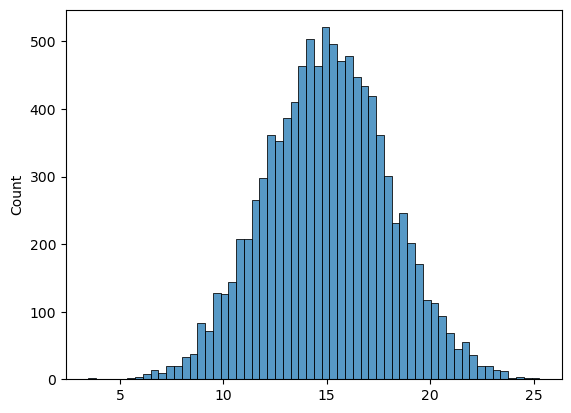

In [7]:
l = []
for k in range(10000):
    l.append(np.random.normal(loc=15, scale=3.0, size=None))
sns.histplot(l)

Que se passe-t-il si on joue avec la size ?

<Axes: ylabel='Count'>

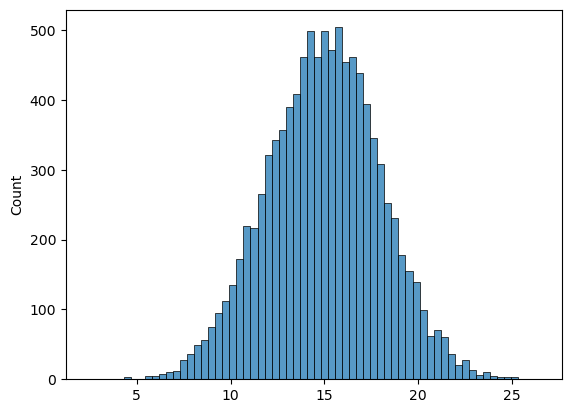

In [8]:
sns.histplot(np.random.normal(loc=15, scale=3.0, size=10000))


# Quelques théorèmes fondamentaux à connaitre en statistiques

## La loi des grands nombres

Ressources :</br>
- 🌞 https://www.youtube.com/watch?v=HRnYFpdR8WM
- https://fr.wikipedia.org/wiki/Loi_des_grands_nombres
- 🌚 https://www.datacamp.com/fr/tutorial/law-of-large-numbers

**En résumé** : elle signifie que la moyenne empirique (calculée sur les valeurs d’un échantillon), converge vers l’espérance (moyenne de la population globale réelle : extrapolation) lorsque la taille de l’échantillon tend vers l’infini.

## Le Théorème Central Limite (TCL)

Ressources :</br>
- 🌞 https://www.youtube.com/watch?v=4dhm2QAA2x4
- 🌞 https://www.youtube.com/watch?v=YAlJCEDH2uY
- https://fr.wikipedia.org/wiki/Th%C3%A9or%C3%A8me_central_limite
- 🌚 https://www.datacamp.com/fr/tutorial/central-limit-theorem
- 🌚 Afin de bien saisir la notion, vous pouvez jouer avec ce simulateur : https://im2ag-shiny.univ-grenoble-alpes.fr/fcorset/TCL/
- 🌚 Un autre petit jeu à explorer pour comprendre : https://probastat.dyndoc.fr/statinf/aep

**En résumé** : il établit la convergence en loi de la somme d'une suite de variables aléatoires vers la loi normale.

# Sujet 1 : Les passagers du Titanic

🌞 Source : https://www.kaggle.com/datasets/vinicius150987/titanic3

## A quoi ressemblent nos données ?

### Importons le jeu de données

In [9]:
df = pd.read_csv("./Data/titanic_complet.csv",sep=";")

In [10]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29,0.0,0.0,24160,"211,3375",B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,"0,9167",1.0,2.0,113781,"151,5500",C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,"14,4542",NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,"26,5",0.0,0.0,2656,"7,2250",NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27,0.0,0.0,2670,"7,2250",NaN,C,NaN,NaN,NaN
1308,3.0,0.0,"Zimmerman, Mr. Leo",male,29,0.0,0.0,315082,"7,8750",NaN,S,NaN,NaN,NaN


### Combien y a-t-il de personnes sur le paquebot ?

In [11]:
df[df["name"].isna()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df[df["name"].duplicated(keep=False)]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
725,3.0,1.0,"Connolly, Miss. Kate",female,22,0.0,0.0,370373,"7,7500",NaN,Q,13,NaN,Ireland
726,3.0,0.0,"Connolly, Miss. Kate",female,30,0.0,0.0,330972,"7,6292",NaN,Q,NaN,NaN,Ireland
924,3.0,0.0,"Kelly, Mr. James",male,"34,5",0.0,0.0,330911,"7,8292",NaN,Q,NaN,70.0,NaN
925,3.0,0.0,"Kelly, Mr. James",male,44,0.0,0.0,363592,"8,0500",NaN,S,NaN,NaN,NaN


In [13]:
df.drop(1309,inplace=True)

In [14]:
df.shape

(1309, 14)

On a 1309 personnes sur le titanic

### Combien d'informations a-t-on sur ces personnes ?

In [15]:
1309 * 14

18326

In [16]:
df.notna().sum().sum()

np.int64(14471)

### Regardons les premières lignes de nos données afin de se faire une idée

In [17]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29,0.0,0.0,24160,"211,3375",B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,"0,9167",1.0,2.0,113781,"151,5500",C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Réalisons un résumé statistique afin d'avoir une idée des chiffres globaux

In [18]:
df.describe()

,pclass,survived,sibsp,parch,body
count,1309.000000,1309.000000,1309.000000,1309.000000,121.000000
mean,2.294882,0.381971,0.498854,0.385027,160.809917
std,0.837836,0.486055,1.041658,0.865560,97.696922
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,72.000000
50%,3.000000,0.000000,0.000000,0.000000,155.000000
75%,3.000000,1.000000,1.000000,0.000000,256.000000
max,3.000000,1.000000,8.000000,9.000000,328.000000


## Analyse univariée : quelles informations pourraient être intéressantes à regarder par variable ?

### Regardons les variables qualitatives

#### Quelles sont les variables qualitatives ?

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   object 
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   object 
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(5), object(9)
memory usage: 143.3+ KB


#### Quelle est la part d'hommes et de femmes ?

Montrons la répartition des effectifs :

In [20]:
(df[df["sex"]=="female"].shape[0] + df[df["sex"]=="male"].shape[0])/df.shape[0]

1.0

In [21]:
print(df[df["sex"]=="female"].shape[0])
print(df[df["sex"]=="male"].shape[0])

466
843


Montrons la répartition en fréquences :

https://fr.wikipedia.org/wiki/Fr%C3%A9quence_(statistiques)

In [22]:
print(df[df["sex"]=="female"].shape[0]/df.shape[0])
print(df[df["sex"]=="male"].shape[0]/df.shape[0])

0.3559969442322384
0.6440030557677616


#### Représentons ça sous forme de graphiques afin que ce soit plus visuel

Diagramme en barres en effectifs :

<Axes: ylabel='sex'>

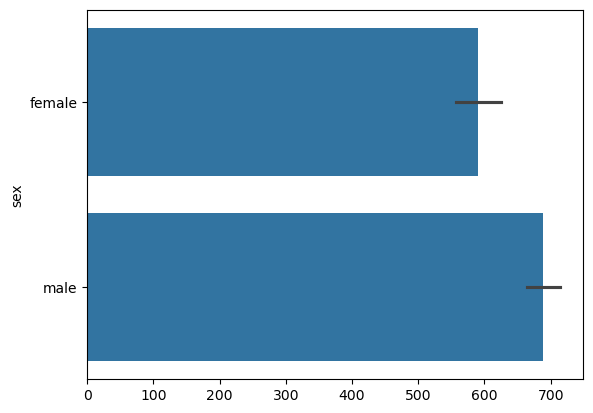

In [23]:
sns.barplot(df["sex"])

Diagramme en barres en proportion :

<Axes: >

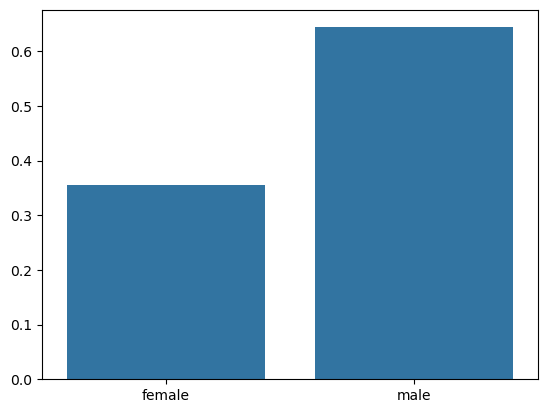

In [24]:
sns.barplot(x=["female","male"],y=[(df[df["sex"]=="female"].shape[0]/df.shape[0]),(df[df["sex"]=="male"].shape[0]/df.shape[0])])

In [25]:
df["survived"].plot(kind="hist")

#### Continuez d'explorer ce qui vous semble intéressant !

In [26]:
df["pclass"].hist()

In [27]:
df["embarked"].hist()

### Regardons les variables quantitatives

#### Quelles sont les variables quantitatives ?

In [28]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29,0.0,0.0,24160,"211,3375",B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,"0,9167",1.0,2.0,113781,"151,5500",C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1.0,2.0,113781,"151,5500",C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,"14,5",1.0,0.0,2665,"14,4542",NaN,C,NaN,328.0,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,"14,4542",NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,"26,5",0.0,0.0,2656,"7,2250",NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27,0.0,0.0,2670,"7,2250",NaN,C,NaN,NaN,NaN


#### Comment est représenté l'âge des voyageurs ?

Regardons le résumé statistiques :

In [29]:
df["age"] = df["age"].str.replace(",",".").astype(float)

In [30]:
df["age"].describe()

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

#### Comment peut-on regarder la répartition de l'âge sous forme de graphique ?

Regardons un diagramme en barre des effectifs / histogramme

In [31]:
df["age"].plot(kind='hist')

Regardons le boxplot :

https://fr.wikipedia.org/wiki/Bo%C3%AEte_%C3%A0_moustaches

<Axes: ylabel='age'>

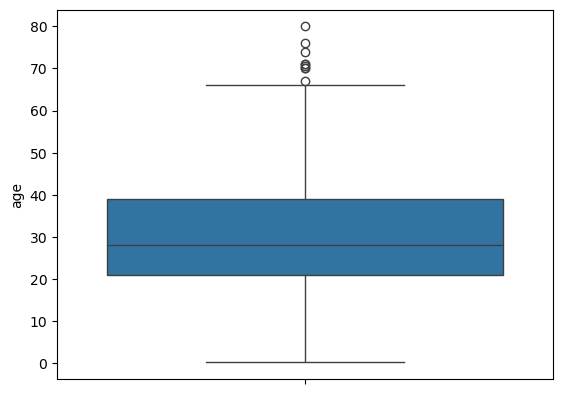

In [32]:
sns.boxplot(df["age"])

#### Continuez d'explorer ce qui vous semble intéressant !

In [33]:
df["fare"] = df["fare"].str.replace(",",".").astype(float)

In [34]:
df["fare"].plot(kind='hist')

## Croisons un peu les variables !

### Quelle est la part de femmes ayant survécu ?

Regardons la table de contingence en effectifs :

In [35]:
df.groupby("sex")["survived"].value_counts()

sex     survived
female  1.0         339
        0.0         127
male    0.0         682
        1.0         161
Name: count, dtype: int64

In [36]:
pd.crosstab(df["sex"],df["survived"])

survived,0.0,1.0
sex,,
female,127,339
male,682,161


Regardons la table de contingence en fréquences :

In [37]:
pd.crosstab(df["sex"],df["survived"],normalize="index")

survived,0.0,1.0
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


### Est-ce que les survivants sont plus des femmes ?

Regardons la table de contingence en proportion en fonction des colonnes

In [38]:
pd.crosstab(df["sex"],df["survived"],normalize="columns")

survived,0.0,1.0
sex,,
female,0.156984,0.678
male,0.843016,0.322


### Est-ce que les femmes sont plus nombreuses à avoir survécu que les hommes ?

Regardons la table de contingence en proportion en fonction des lignes

In [39]:
pd.crosstab(df["sex"],df["survived"],normalize="index")

survived,0.0,1.0
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


### Observons ça en graphiques !

Réalisons un diagramme en barres en effectifs

<Axes: xlabel='sex', ylabel='count'>

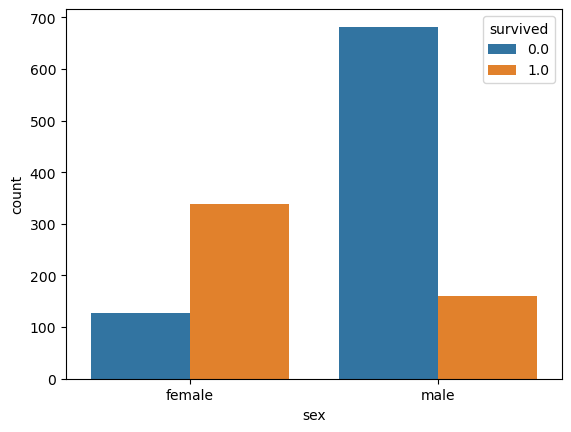

In [40]:
sns.countplot(df, x="sex", hue="survived")

In [41]:
pd.crosstab(df["sex"],df["survived"]).plot(kind='bar')

### Comment sont représentés les âges par genre ?

Réalisons le résumé statistique par modalité :

In [42]:
df.groupby("sex")["age"].describe().T

sex,female,male
count,388.000000,658.000000
mean,28.687071,30.585233
std,14.576995,14.280571
min,0.166700,0.333300
25%,19.000000,21.000000
50%,27.000000,28.000000
75%,38.000000,39.000000
max,76.000000,80.000000


### Regardons ça en graphiques !

Avec le boxplot :

<Axes: xlabel='sex', ylabel='age'>

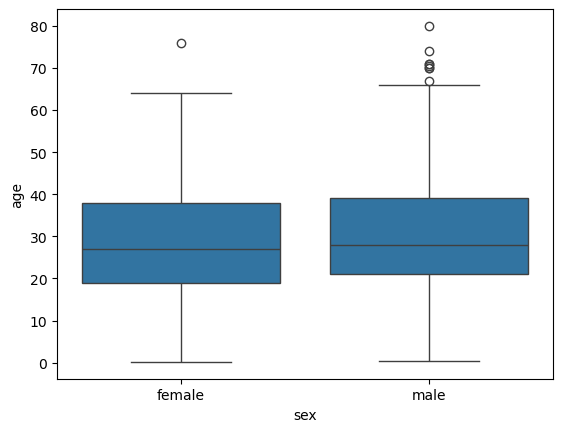

In [43]:
sns.boxplot(df,x="sex",y="age")

Avec la fonction de répartition empirique :

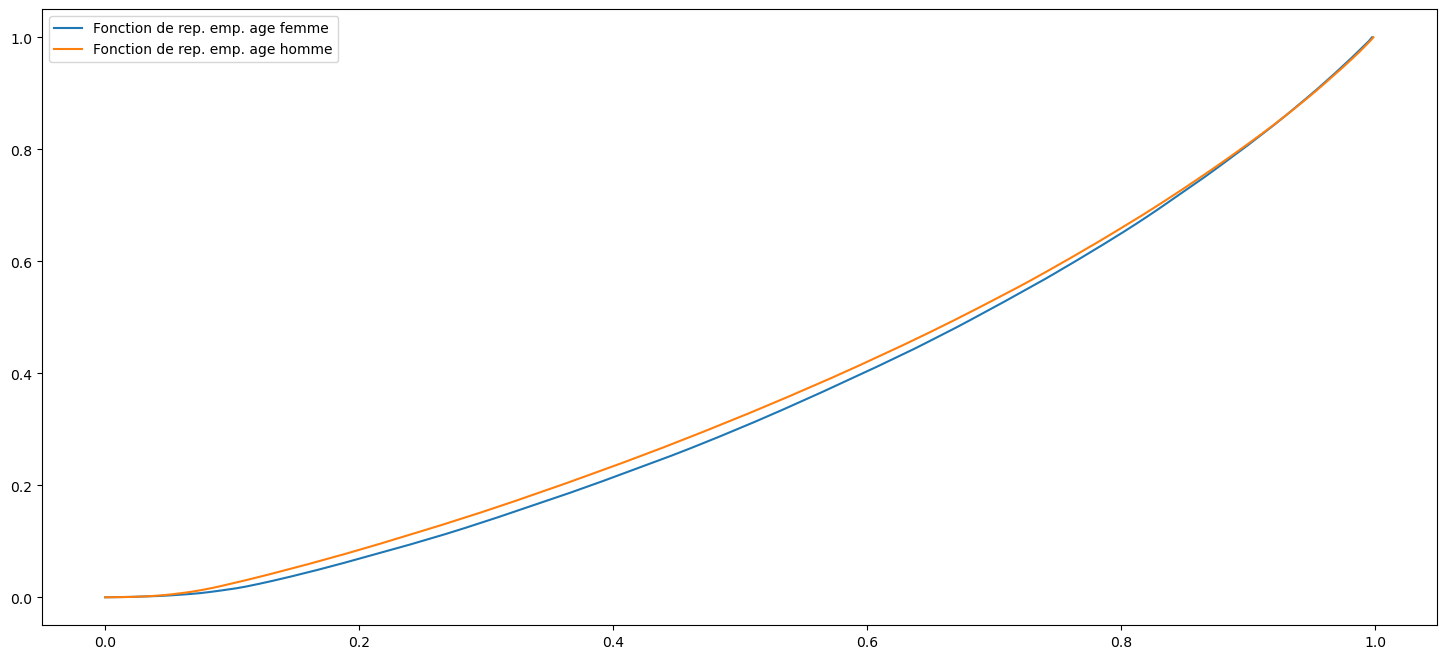

In [109]:
fig, ax = plt.subplots(figsize=(18,8))
age_femme = df[df["sex"]=="female"]["age"].dropna().sort_values().values
x = np.array(range(len(age_femme)))/len(age_femme)
y = age_femme.cumsum()/(age_femme.sum())
ax.plot(x,y,label="Fonction de rep. emp. age femme")
age_homme = df[df["sex"]=="male"]["age"].dropna().sort_values().values
x = np.array(range(len(age_homme)))/len(age_homme)
y = age_homme.cumsum()/(age_homme.sum())
ax.plot(x,y,label="Fonction de rep. emp. age homme")
ax.legend()

### Peut-on voir un lien entre l'âge et le prix du ticket ?

Regardons ça avec un scatter plot :

In [45]:
df.plot.scatter(x="fare",y="age")

Regardons le coefficient de corrélation :

In [46]:
df["age"].corr(df["fare"])

np.float64(0.17873932314646124)

Réalisons la matrice de corrélation en heatmap pour voir ça graphiquement :

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(7), object(7)
memory usage: 143.3+ KB


<Axes: >

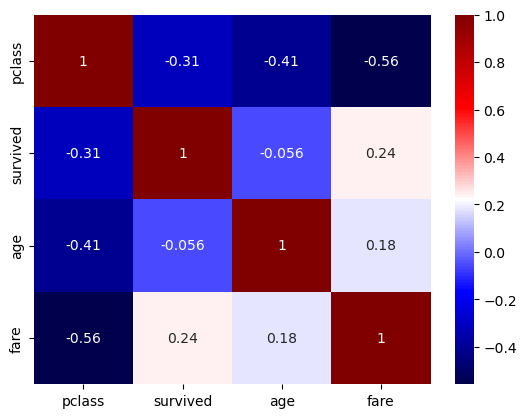

In [48]:
sns.heatmap(df[["pclass","survived","age","fare"]].corr(),annot=True,cmap="seismic")

Par défaut, la fonction .corr() calcule la <b/>corrélation de Pearson</b>, adaptée lorsque la relation entre les deux variables est linéaire.<br/>
La <b/>corrélation de Spearman</b> quant à elle mesure la relation monotone entre deux variables en se basant sur les rangs des données. Elle est ainsi moins sensible aux outliers et permet de repérer des relations monotones non linéaires.<br/>

🌞 Ressource : https://datascientest.com/correlations-de-pearson-et-de-spearman <br/>

Calculer le coefficient de corrélation de Spearman et comparer le résultat.

<Axes: >

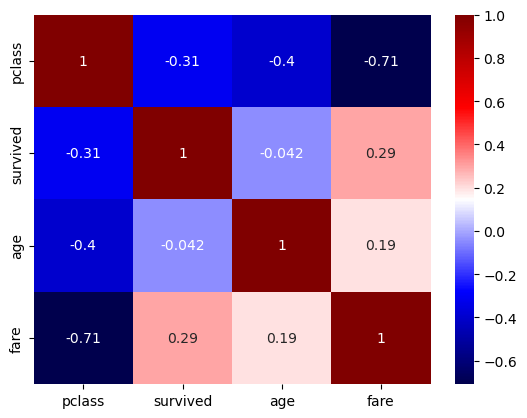

In [49]:
sns.heatmap(df[["pclass","survived","age","fare"]].corr(method="spearman"),annot=True,cmap="seismic")

In [50]:
df["age"].corr(df["fare"],method="spearman")

np.float64(0.19267576103868872)

### Semble-t-il y avoir un lien entre la classe sociale et la survie ?

In [51]:
df["survived"].corr(df["pclass"],method="spearman")

np.float64(-0.3097338593294455)

<Axes: xlabel='pclass', ylabel='count'>

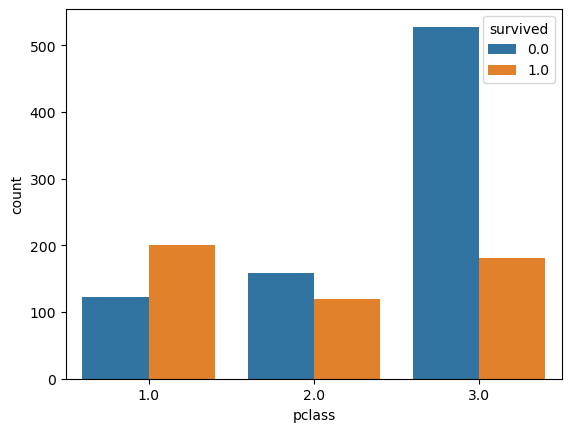

In [52]:
sns.countplot(df, x="pclass", hue="survived")

In [53]:
df.groupby("pclass")["survived"].mean().plot(kind="bar",title="Proportion de survie, par rapport à la classe")

### Continuez d'explorer ce qui vous semble intéressant !

<Axes: xlabel='pclass', ylabel='age'>

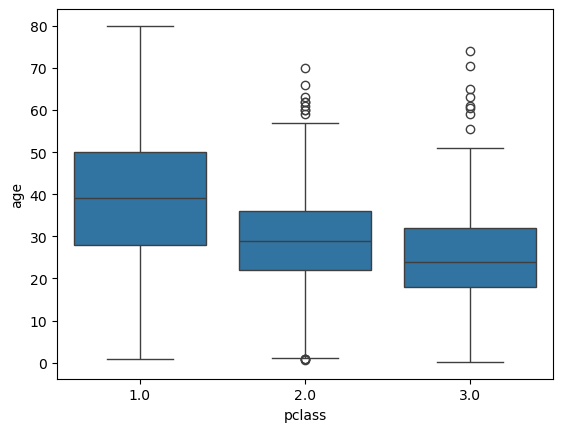

In [54]:
sns.boxplot(df,x="pclass",y="age")

<Axes: xlabel='survived', ylabel='age'>

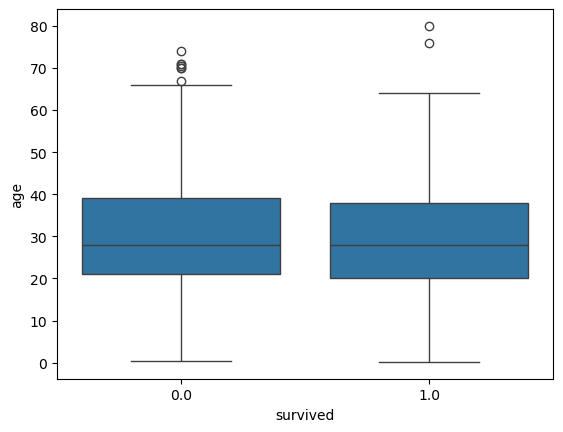

In [55]:
sns.boxplot(df,x="survived",y="age")

## Tests statistiques

Nous avons pu voir plusieurs informations avec les analyses préliminaires réalisées :
- Les femmes semblent être plus nombreuses à survivre
- Les 1ère classes semblent avoir plus de chance de survivre que les 3ème classe
- ...

### Qu'est-ce qu'un test d'hypothèses ?

Quelques ressources :
- 🌞 https://www.youtube.com/watch?v=0oc49DyA3hU
- 🌞 https://www.youtube.com/watch?v=5koKb5B_YWo

Idée principale : vérifier que les statistiques de l'échantillon sont significatives, c'est à dire que si on reproduit l'expérience, on aurait les mêmes résultats (extrapolation à la population globale).

Autrement dit : à partir des conclusions faites sur un <b/>échantillon</b>, on veut voir si on peut les <b/>généraliser à l'ensemble de la population</b> dont est tiré cet échantillon.

Par exemple si on analyse un échantillon de personnes ayant un cancer en testant deux méthodes pour le soigner et qu'on trouve que la meilleure des solutions est de dormir 12h par nuit, on souhaite que nos statistiques sur cet échantillon soient valables pour toutes les personnes ayant un cancer afin d'être sûre que cette méthode peut être utilisée sur tout le monde.<br/>
<br/>

Il existe différents types de tests, notamment :
- les tests <b/>de conformité à une valeur</b> <i/>(ex : les paquets de farine de ma chaîne de production font-ils bien 500g ?)</i>
- les tests <b/>de comparaison entre des échantillons</b> <i/>(ex : est-ce que les fumeurs ont davantage de risque de cancer que les non fumeurs ?)</i>
- les tests <b/>d'adéquation / de conformité à une loi de probabilité</b> <i/>(ex : est-ce que la distribution des revenus suit une loi normale ?)</i>

Dans chacun des cas, on utilisera une formule spécifique à ce type de test (une fonction différente sur Python).

🌚 Ressource pour plus tard : guide de choix de test statistique - https://hal.science/hal-04292194v1/file/Arbreded%C3%A9cision2023.pdf

Commençons par les tests de comparaison de deux moyennes.

### Les femmes ont-elles significativement plus de chance de survie que les hommes ?

Ou la répartition est-elle due au hasard ?

Peut-être que vous vous demandez : ça se voit avec les effectifs, pourquoi le vérifier statistiquement ?

L'idée des tests d'hypothèses est d'extrapoler ce qu'on voit sur un échantillon à la population globale. Dans notre cas, c'est comme si on voulait vérifier si à l'époque la survie des femmes sur les bâteaux qui rencontrent des icebergs est toujours supérieure à celle des hommes. Pour cela on prend notre échantillon du Titanic en référence.

De la même manière, vous avez peut-être déjà entendu parlé de ça en politique pendant les élections, on peut prendre un village qui aurait les mêmes proportions de femmes, de jeunes, d'artisans,... que la France entière (= échantillon) afin d'extrapoler leurs intentions de vote au niveau national.

**Réalisons notre premier test statistique pas à pas !**

Commençons par réaliser les sous-échantillons d'hommes et de femmes :

In [56]:
df[df["sex"]=="female"]
df[df["sex"]=="male"]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
5,1.0,1.0,"Anderson, Mr. Harry",male,48.0000,0.0,0.0,19952,26.5500,E12,S,3,NaN,"New York, NY"
7,1.0,0.0,"Andrews, Mr. Thomas Jr",male,39.0000,0.0,0.0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
9,1.0,0.0,"Artagaveytia, Mr. Ramon",male,71.0000,0.0,0.0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1302,3.0,0.0,"Yousif, Mr. Wazli",male,NaN,0.0,0.0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3.0,0.0,"Yousseff, Mr. Gerious",male,NaN,0.0,0.0,2627,14.4583,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN


Calculons le taux de survie dans chaque échantillon pour vérifier que notre hypothèse est plausible :

In [57]:
print(f"Taux de survie des femmes : {round(df[df["sex"]=="female"]["survived"].mean(),2)}")
print(f"Taux de survie des hommes : {round(df[df["sex"]=="male"]["survived"].mean(),2)}")

Taux de survie des femmes : 0.73
Taux de survie des hommes : 0.19


Réalisons un premier test afin de voir si les deux proportions sont statistiquement significativement différentes :

Quelques petites informations intéressantes, prenez le temps d'y jeter un coup d'oeil :
- Documentation Python :
    - Test sur une moyenne : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html#scipy.stats.ttest_1samp
    - Test de comparaison de 2 moyennes : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
    - Test sur une proportion : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html
    - Test de comparaison de 2 proportions : https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
    - 🌚 Tous les tests d'hypothèse sur Python : https://docs.scipy.org/doc/scipy/reference/stats.html#hypothesis-tests-and-related-functions <br/>
<br/>
- 🌞 Les étapes de la réalisation d'un test d'hypothèses : https://www.youtube.com/watch?v=I3vnzM1X15g&list=PLWwpP-YNkDjYa9PTCOwJ0A6LNtvbjThsf&index=1

A noter que dans la plupart des cas (notamment quand ce n'est pas précisé), on prendra à une pvaleur à 5%

On pose nos hypothèses H0 et H1 :

In [58]:
# H0 : Il n'y a pas un écart sinificatif entre le taux de survie des hommes et des femmes
# H1 : Cet écart existe

On réalise notre test :

In [59]:
df[df["sex"]=="male"]["survived"].std()

0.39331027503230787

In [60]:
df[df["sex"]=="female"]["survived"].std()

0.4457406836111837

In [61]:
# TEST PAR COMPARAISON DE 2 MOYENNE
# Ici ont est dans un test d'homogénéité avec des variances proches,  
stats.ttest_ind(df[df["sex"]=="female"]["survived"],df[df["sex"]=="male"]["survived"])

TtestResult(statistic=np.float64(22.51797718552575), pvalue=np.float64(3.775892357945091e-95), df=np.float64(1307.0))

Analyse des résultats et conclusion :

In [62]:
# On a une p-values de l'orde de 10^-95 soit extrement faible par rapport a 0.05 on peut donc rejetter H0

On peut refaire le test en vérifiant que la survie des femmes est supérieure à celle des hommes :

In [63]:
# H0 : La proportion de femme ayant survecue n'est pas superieur a celle des homme ayant survecu

In [64]:
# TEST PAR COMPARAISON DE 2 PROPORTION
count = [df[df["sex"]=="female"]["survived"].sum(),df[df["sex"]=="male"]["survived"].sum()]
nobs = [df[df["sex"]=="female"]["survived"].count(),df[df["sex"]=="male"]["survived"].count()]
print(count)
print(nobs)
stat, pval = proportions_ztest(count,nobs,alternative='larger')
print(pval)

[np.float64(339.0), np.float64(161.0)]
[np.int64(466), np.int64(843)]
7.35726550846066e-82


Conclusion :

In [ ]:
# On peu rejeter H0 avec un rique d'erreur de l'ordre de 10^-82

### Focus pvalue + intervalle de confiance

Quelques ressources pour bien comprendre la notion de pvaleur :
- https://fr.wikipedia.org/wiki/Valeur_p
- 🌞 https://www.youtube.com/watch?v=vemZtEM63GY
- 🌞 https://www.youtube.com/watch?v=xVIt51ybvu0
- 🌚 https://www.youtube.com/watch?v=jy9b1HSqtSk

Quelques ressources pour bien comprendre la notion d'intervalle de confiance :
- https://fr.wikipedia.org/wiki/Intervalle_de_confiance
- 🌞 https://www.youtube.com/watch?v=TqOeMYtOc1w
- 🌚 simulateur pour aider à la compréhension : https://im2ag-shiny.univ-grenoble-alpes.fr/fcorset/ICmu/

### COMPETENCE - Les 3ème classe ont-il moins de chance de survie que les 1ère classe ?

<Axes: xlabel='pclass', ylabel='count'>

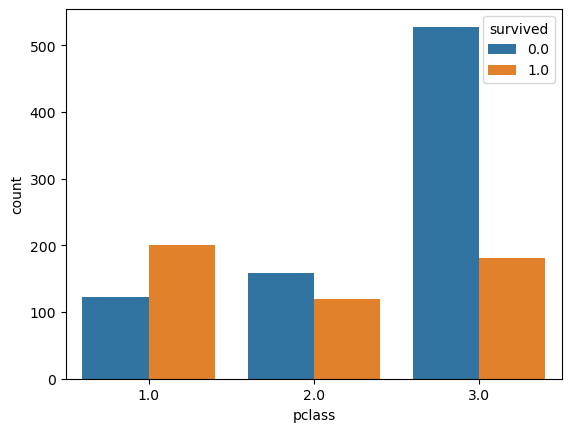

In [66]:
sns.countplot(df, x="pclass", hue="survived")

In [132]:
#H0 : Les 1ere classes ont auttant ou moins de chance de survivre que les 3ere classe
#H1 : Les 1eme classes ont plus de chance de survivre que les 3ere classe

# TEST PAR COMPARAISON DE 2 PROPORTION

count = [df[df["pclass"]==1]["survived"].sum(),df[df["pclass"]==3]["survived"].sum()]
nobs = [df[df["pclass"]==1]["survived"].count(),df[df["pclass"]==3]["survived"].count()]

stat, pval = proportions_ztest(count,nobs,alternative='larger')
print(f"pvalue = {pval}")

pvalue = 1.4020149069770155e-29


In [68]:
# TEST PAR COMPARAISON DE 2 MOYENNE (le taux de survit des 2 classe)

stats.ttest_ind(df[df["pclass"]==1]["survived"],df[df["pclass"]==3]["survived"],alternative='greater')

TtestResult(statistic=np.float64(11.978397439866121), pvalue=np.float64(2.3909051760078196e-31), df=np.float64(1030.0))

In [69]:
# Les 2 test ont une p-value extrement faible on peut donc rejeuter H0

##### Qu'en est-il des 2nde classe ?

In [70]:
stats.ttest_ind(df[df["pclass"]==1]["survived"],df[df["pclass"]==2]["survived"],alternative='greater')

TtestResult(statistic=np.float64(4.717344242779382), pvalue=np.float64(1.4886983836810634e-06), df=np.float64(598.0))

In [71]:
stats.ttest_ind(df[df["pclass"]==2]["survived"],df[df["pclass"]==3]["survived"],alternative='greater')

TtestResult(statistic=np.float64(5.42074634595636), pvalue=np.float64(3.733498041485678e-08), df=np.float64(984.0))

In [134]:
print(f"On peu donc dire en étant sure à {(1 - np.float64(1.4886983836810634e-06))*100}% les 1ere classes ont plus de chance de survie que les 2nd classes")
print(f"On peu donc dire en étant sure à {(1 - np.float64(3.733498041485678e-08))*100}% les 2nd classes ont plus de chance de survie que les 3eme classes")

On peu donc dire en étant sure à 99.99985113016163% les 1ere classes ont plus de chance de survie que les 2nd classes
On peu donc dire en étant sure à 99.99999626650195% les 2nd classes ont plus de chance de survie que les 3eme classes


### Les chances de survie des mineurs étaient-elles supérieures à 50% ?

Identifier le type de test à réaliser parmi ceux cités plus haut.

In [73]:
df[df["age"]<18]["survived"].mean()

np.float64(0.525974025974026)

In [74]:
#H0 les chances de survie des mineur est inferieur ou égale à 50%
# TEST SUR 1 MOYENNE
stats.ttest_1samp(df[df["age"]<18]["survived"],0.5,alternative="greater")

TtestResult(statistic=np.float64(0.6434306832441478), pvalue=np.float64(0.26045395706419483), df=np.int64(153))

In [75]:
# La pvalues a 0.26 ne permet pas de rejetter H0

In [76]:
# TEST SUR 1 PROPORTION
k = int(df[df["age"]<18]["survived"].sum())
n = df[df["age"]<18]["survived"].count()
stats.binomtest(k,n,p=0.5,alternative="greater")

BinomTestResult(k=81, n=154, alternative='greater', statistic=0.525974025974026, pvalue=0.286422984499854)

In [77]:
# La pvalues a 0.29 ne permet pas de rejetter H0

### Le genre et la survie sont-elles deux variables indépendantes ?

Une autre manière d'aborder la question de la survie selon le genre est de réaliser un test d'indépendance du Khi-deux.<br/>
<br/>
🌞 Ressources :
- Pour expliquer ce test : https://datatab.fr/tutorial/chi-square-test
- Test du Khi-deux d'indépendance sur Python : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

In [110]:
# Tableau de contingence avec crosstab
pd.crosstab(df["sex"],df["survived"])

survived,0.0,1.0
sex,,
female,127,339
male,682,161


In [112]:
# Test du Khi-deux
# H0 il n'y a pas de relation entre la survie et le genre
stats.chi2_contingency(pd.crosstab(df["sex"],df["survived"]))

Chi2ContingencyResult(statistic=np.float64(363.6179084388249), pvalue=np.float64(4.589924936952945e-81), dof=1, expected_freq=array([[288.00152788, 177.99847212],
       [520.99847212, 322.00152788]]))

In [ ]:
# P-values extremement faible permet de rejeter H0
# Les variable ne sont donc pas indépendantes

### COMPETENCE - Y a-t-il un lien entre le genre et la classe ?

<Axes: xlabel='pclass', ylabel='count'>

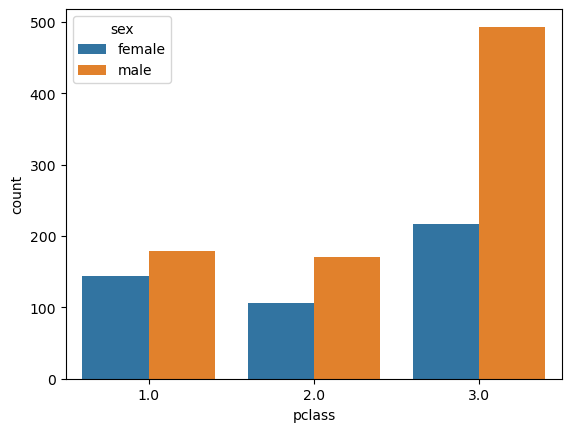

In [114]:
sns.countplot(df, x="pclass", hue="sex")

In [ ]:
# TEST KHI-2 
# H0 il n'y a pas de lien entre genre et classe
stats.chi2_contingency(pd.crosstab(df["sex"],df["pclass"]))

Chi2ContingencyResult(statistic=np.float64(20.378781205085588), pvalue=np.float64(3.7566772719164024e-05), dof=2, expected_freq=array([[114.98701299,  98.61115355, 252.40183346],
       [208.01298701, 178.38884645, 456.59816654]]))

In [ ]:
# La p-values de 0.000037 permet de rejetter H0 -> sex et class ne sont pas indépendant


# cepandant, la classe étant une variable ordinal la vidéo conseil un test différent plus adapter a traiter 1 variable nominal et  1 ordinal :
# Spearman coorelation
# Mann-Whitney U test
# Kurskal-Wallis test

In [ ]:
# Mann-Whitney U test
stats.mannwhitneyu(df[df["sex"]=="female"]["pclass"],df[df["sex"]=="male"]["pclass"])

MannwhitneyuResult(statistic=np.float64(169769.0), pvalue=np.float64(6.6902414446789485e-06))

In [ ]:
# Kurskal-Wallis test
stats.kruskal(df[df["sex"]=="female"]["pclass"],df[df["sex"]=="male"]["pclass"])

KruskalResult(statistic=np.float64(20.280583900515367), pvalue=np.float64(6.687580947104471e-06))

In [ ]:
# Effectivement avec ces 2 test on a un p-values 5 fois plus faible qu'avec le test KHI2 , donc on peu encore plus refuter H0

# Petite pause avec le paradoxe de Simpson

🌞 https://www.youtube.com/watch?v=vs_Zzf_vL2I

# Sujet 2 : Enquête sur le bonheur

Des étudiants en Master 1 Sciences Des Données à l'Université Grenoble Alpes ont réalisée une étude sur le bonheur lors d'un de leurs projets tutorés en 2020

Importez les données :

In [86]:
dfb = pd.read_csv("./Data/enquete_sur_le_bonheur.csv",sep=";")

Regardez globalement ce qu'il y a dedans :

## Traitement

In [9]:
dfb

,Timestamp,Quel est votre sexe ?,Quel est votre âge ? (Ex : 30 pour 30 ans),Dans quel département habitez-vous ? (Ex : 38 pour l'Isère / 0 si hors France),Etes vous heureux ?,Accordez-vous de l'importance à ... ? (Cochez si oui),Vous épanouissez-vous dans votre travail ?,Accordez-vous de l'importance à l'argent ?,Etes-vous plutôt ville ou nature ?,Accordez-vous de l'importance à votre temps personnel ?,Accordez-vous de l'importance aux activités sportives ?,Accordez-vous de l'importance aux activités créatives ?,Prenez-vous soin de votre santé ?,Accordez-vous de l'importance à votre développement personnel ?,Quel était votre rêve d'enfant ?,"Si vous fermez les yeux et imaginez un endroit où vous vous sentez bien, comment le décririez-vous ?",Que faites vous qui vous rende heureux pendant votre temps personnel ?,Qu'est ce qui vous rend heureux au quotidien ?,Quel est votre but dans la vie ?,Qu'est-ce qu'être heureux selon vous ?
0,9/29/2020 18:16:11,Femme,24,38,3,"Votre famille, Vos amis, Vos relations amoureu...",3.0,2,5,5,2,5,2,5,Je rêvais d'être artiste et d'avoir plein d'an...,"C'est une vaste plaine, avec énormément de fle...","Des créations artistiques (bijoux, dessins, br...",Savoir que les personnes qui m'entourent vont ...,"Être heureux, trouver le bonheur.","Être dans un bon état d'esprit, sans angoissé ..."
1,9/29/2020 18:19:18,Femme,22,38,4,"Votre famille, Vos amis, Vos relations amoureu...",3.0,5,4,5,2,1,3,2,Je n'avais pas de rêve quand j'étais enfant.,"Un endroit ni calme, ni bruyant, confortableme...","Manger, ou dormir.","Les petits plaisirs de la vie, la colloc, la f...","Je n'en ai pas spécialement, avoir les bonnes ...","Pour moi, c'est être satisfait de soi-même, de..."
2,9/29/2020 18:26:09,Femme,24,38,4,"Votre famille, Vos amis, Vos relations amoureu...",5.0,3,4,2,4,5,5,2,Je revaiq de devenir fermière et d'élever des ...,Une table de Noël avec toute ma famille et les...,Je prend soin de moi,Etre avec les gens que j'aime,Fonder une famille plein d'amour,"Etre bien dans sa peau, dans sa vie. Et être e..."
3,9/29/2020 18:28:35,Femme,30,1,4,"Votre famille, Vos amis, Vos relations amoureuses",4.0,5,4,3,2,4,4,2,Avoir des enfants,"Dans la nature, surtout près de l'eau",Prendre du temps pour moi,"Ma maison, mes chats, mon chéri",Être pleinement épanouie entre ma vie perso (u...,"Accomplir son objectif de vie, faire ce qui no..."
4,9/29/2020 18:30:32,Homme,33,77,4,"Votre famille, Vos amis, Vos relations amoureuses",3.0,5,1,5,3,3,3,3,devenir footballeur,Avec ma famille dans un parc,Me reposer,Manger et se reposer,Que ma famille ne manque de rien,Avoir la paix intérieure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,10/12/2020 10:02:00,Femme,29,38,4,"Votre famille, Vos amis, Vos relations amoureu...",4.0,1,5,5,4,4,4,4,Je ne me rappelle plus si j'en avais un,Assise dans la nature devant un beau ciel colo...,"Je partage du temps avec mes amis, ma famille,...",Idem + partager avec mes adorables étudiants,Être heureuse,Profiter des petits moments partagés avec mes ...
419,10/12/2020 13:21:43,Homme,63,974,4,"Votre famille, Vos amis, Vos relations amoureuses",4.0,4,3,4,5,2,4,4,Devenir vétérinaire,"Un endroit avec de la verdure, de la chaleur, ...",Des câlins,"Le soleil, la vue de l'océan, les oiseaux qui ...",être heureux et sans pb d'argent,"Avant toute chose, une santé de fer. Puis un s..."
420,10/12/2020 19:25:39,Femme,21,69,3,"Votre famille, Vos amis, Vos relations amoureu...",5.0,5,4,4,3,4,5,5,Etre une chanteuse et remplir des salles de sp...,"Je me vois sur une plage de galets, avec le br...","Je fais du sport, de la musique, je chante, je...",Développer un peu plus chaque jour des relatio...,"Avoir un métier stimulant, qui me permette de ...",Pouvoir manger sans grossir !
421,10/12/2020 21:53:41,Femme,22,69,4,"Votre famille, Vos amis, Vos relations amoureu...",4.0,4,3,4,5,1,3,3,Devenir chanteuse,"Calme, au bord de la mer et entourée des perso...","Du sport, profiter de ma fam

In [87]:
dfb.convert_dtypes()
dfb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 20 columns):
 #   Column                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                --------------  -----  
 0   Timestamp                                                                                             423 non-null    object 
 1   Quel est votre sexe ?                                                                                 423 non-null    object 
 2   Quel est votre âge ? (Ex : 30 pour 30 ans)                                                            423 non-null    int64  
 3   Dans quel département habitez-vous ? (Ex : 38 pour l'Isère / 0 si hors France)                        423 non-null    int64  
 4   Etes vous heureux ?                                                                                   42

In [88]:
dfb.columns = dfb.columns.str.replace(" ","_")

## Exploration

In [89]:
dfb

,Timestamp,Quel_est_votre_sexe_?,Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans),Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l'Isère_/_0_si_hors_France),Etes_vous_heureux_?,Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui),Vous_épanouissez-vous_dans_votre_travail_?,Accordez-vous_de_l'importance_à_l'argent_?,Etes-vous_plutôt_ville_ou_nature_?,Accordez-vous_de_l'importance_à_votre_temps_personnel_?,Accordez-vous_de_l'importance_aux_activités_sportives_?,Accordez-vous_de_l'importance_aux_activités_créatives_?,Prenez-vous_soin_de_votre_santé_?,Accordez-vous_de_l'importance_à_votre_développement_personnel_?,Quel_était_votre_rêve_d'enfant_?,"Si_vous_fermez_les_yeux_et_imaginez_un_endroit_où_vous_vous_sentez_bien,_comment_le_décririez-vous_?",Que_faites_vous_qui_vous_rende_heureux_pendant_votre_temps_personnel_?,Qu'est_ce_qui_vous_rend_heureux_au_quotidien_?,Quel_est_votre_but_dans_la_vie_?,Qu'est-ce_qu'être_heureux_selon_vous_?
0,9/29/2020 18:16:11,Femme,24,38,3,"Votre famille, Vos amis, Vos relations amoureu...",3.0,2,5,5,2,5,2,5,Je rêvais d'être artiste et d'avoir plein d'an...,"C'est une vaste plaine, avec énormément de fle...","Des créations artistiques (bijoux, dessins, br...",Savoir que les personnes qui m'entourent vont ...,"Être heureux, trouver le bonheur.","Être dans un bon état d'esprit, sans angoissé ..."
1,9/29/2020 18:19:18,Femme,22,38,4,"Votre famille, Vos amis, Vos relations amoureu...",3.0,5,4,5,2,1,3,2,Je n'avais pas de rêve quand j'étais enfant.,"Un endroit ni calme, ni bruyant, confortableme...","Manger, ou dormir.","Les petits plaisirs de la vie, la colloc, la f...","Je n'en ai pas spécialement, avoir les bonnes ...","Pour moi, c'est être satisfait de soi-même, de..."
2,9/29/2020 18:26:09,Femme,24,38,4,"Votre famille, Vos amis, Vos relations amoureu...",5.0,3,4,2,4,5,5,2,Je revaiq de devenir fermière et d'élever des ...,Une table de Noël avec toute ma famille et les...,Je prend soin de moi,Etre avec les gens que j'aime,Fonder une famille plein d'amour,"Etre bien dans sa peau, dans sa vie. Et être e..."
3,9/29/2020 18:28:35,Femme,30,1,4,"Votre famille, Vos amis, Vos relations amoureuses",4.0,5,4,3,2,4,4,2,Avoir des enfants,"Dans la nature, surtout près de l'eau",Prendre du temps pour moi,"Ma maison, mes chats, mon chéri",Être pleinement épanouie entre ma vie perso (u...,"Accomplir son objectif de vie, faire ce qui no..."
4,9/29/2020 18:30:32,Homme,33,77,4,"Votre famille, Vos amis, Vos relations amoureuses",3.0,5,1,5,3,3,3,3,devenir footballeur,Avec ma famille dans un parc,Me reposer,Manger et se reposer,Que ma famille ne manque de rien,Avoir la paix intérieure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,10/12/2020 10:02:00,Femme,29,38,4,"Votre famille, Vos amis, Vos relations amoureu...",4.0,1,5,5,4,4,4,4,Je ne me rappelle plus si j'en avais un,Assise dans la nature devant un beau ciel colo...,"Je partage du temps avec mes amis, ma famille,...",Idem + partager avec mes adorables étudiants,Être heureuse,Profiter des petits moments partagés avec mes ...
419,10/12/2020 13:21:43,Homme,63,974,4,"Votre famille, Vos amis, Vos relations amoureuses",4.0,4,3,4,5,2,4,4,Devenir vétérinaire,"Un endroit avec de la verdure, de la chaleur, ...",Des câlins,"Le soleil, la vue de l'océan, les oiseaux qui ...",être heureux et sans pb d'argent,"Avant toute chose, une santé de fer. Puis un s..."
420,10/12/2020 19:25:39,Femme,21,69,3,"Votre famille, Vos amis, Vos relations amoureu...",5.0,5,4,4,3,4,5,5,Etre une chanteuse et remplir des salles de sp...,"Je me vois sur une plage de galets, avec le br...","Je fais du sport, de la musique, je chante, je...",Développer un peu plus chaque jour des relatio...,"Avoir un métier stimulant, qui me permette de ...",Pouvoir manger sans grossir !
421,10/12/2020 21:53:41,Femme,22,69,4,"Votre famille, Vos amis, Vos relations amoureu...",4.0,4,3,4,5,1,3,3,Devenir chanteuse,"Calme, au bord de la mer et entourée des perso...","Du sport, profiter de ma fam

In [90]:
dfb.columns

Index(['Timestamp', 'Quel_est_votre_sexe_?',
       'Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)',
       'Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l'Isère_/_0_si_hors_France)',
       'Etes_vous_heureux_?',
       'Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)',
       'Vous_épanouissez-vous_dans_votre_travail_?',
       'Accordez-vous_de_l'importance_à_l'argent_?',
       'Etes-vous_plutôt_ville_ou_nature_?',
       'Accordez-vous_de_l'importance_à_votre_temps_personnel_?',
       'Accordez-vous_de_l'importance_aux_activités_sportives_?',
       'Accordez-vous_de_l'importance_aux_activités_créatives_?',
       'Prenez-vous_soin_de_votre_santé_?',
       'Accordez-vous_de_l'importance_à_votre_développement_personnel_?',
       'Quel_était_votre_rêve_d'enfant_?',
       'Si_vous_fermez_les_yeux_et_imaginez_un_endroit_où_vous_vous_sentez_bien,_comment_le_décririez-vous_?',
       'Que_faites_vous_qui_vous_rende_heureux_pendant_votre_temps_personnel_?',
       'Qu'est_ce

In [13]:
dfb["Etes_vous_heureux_?"].hist()

<Axes: >

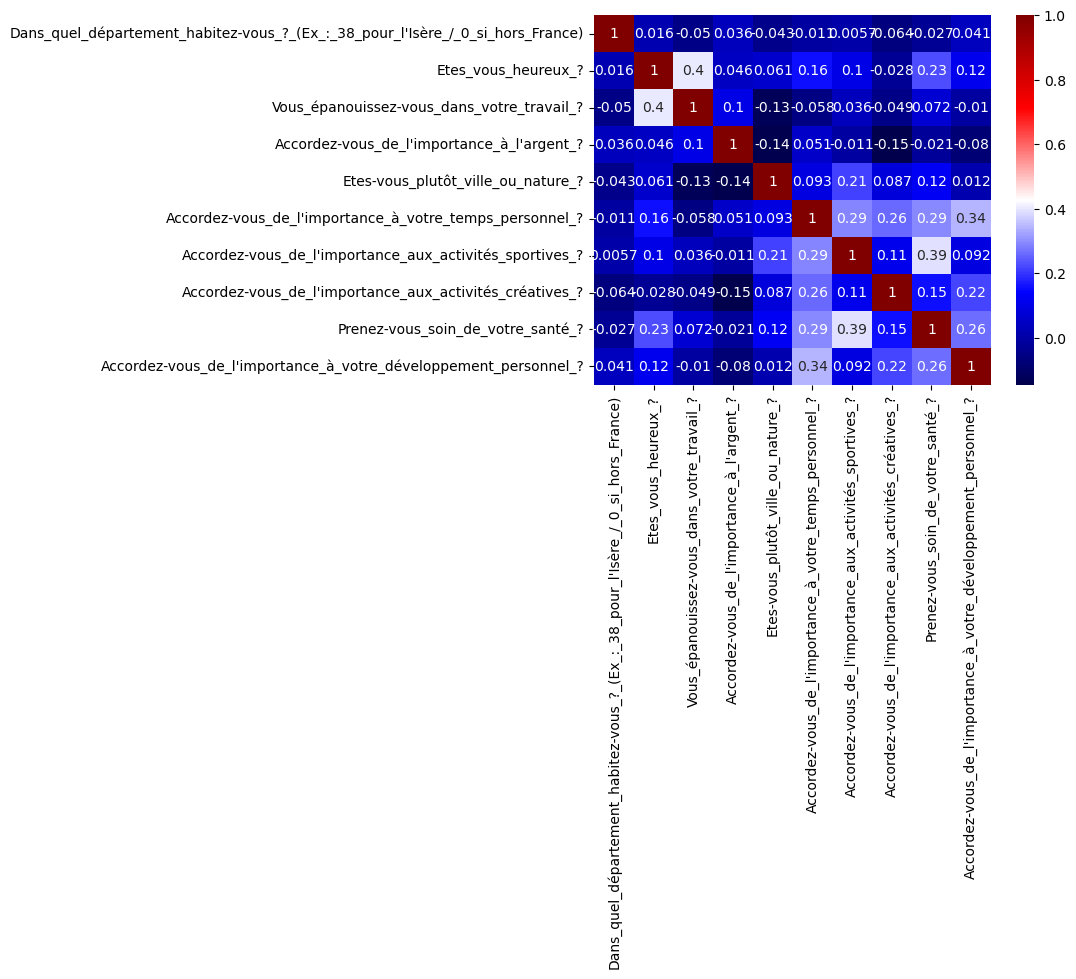

In [14]:
col_quant = ["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l'Isère_/_0_si_hors_France)",'Etes_vous_heureux_?','Vous_épanouissez-vous_dans_votre_travail_?',"Accordez-vous_de_l'importance_à_l'argent_?",
       'Etes-vous_plutôt_ville_ou_nature_?',
       "Accordez-vous_de_l'importance_à_votre_temps_personnel_?",
       "Accordez-vous_de_l'importance_aux_activités_sportives_?",
       "Accordez-vous_de_l'importance_aux_activités_créatives_?",
       'Prenez-vous_soin_de_votre_santé_?',
       "Accordez-vous_de_l'importance_à_votre_développement_personnel_?",]

cor = dfb[col_quant].corr(method="spearman")
sns.heatmap(cor,annot=True,cmap="seismic")

<Axes: >

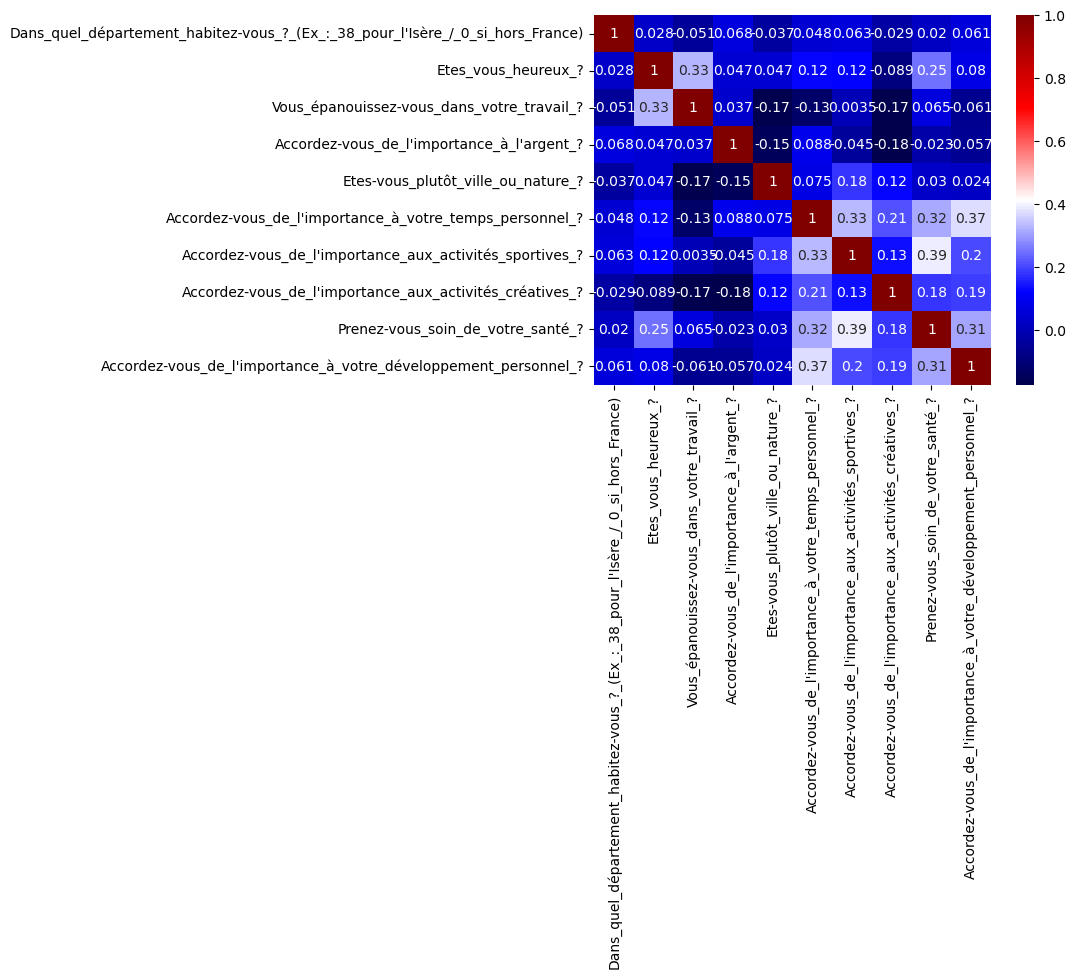

In [15]:
cor = dfb[dfb["Quel_est_votre_sexe_?"]=="Femme"][col_quant].corr(method="spearman")
sns.heatmap(cor,annot=True,cmap="seismic")

<Axes: >

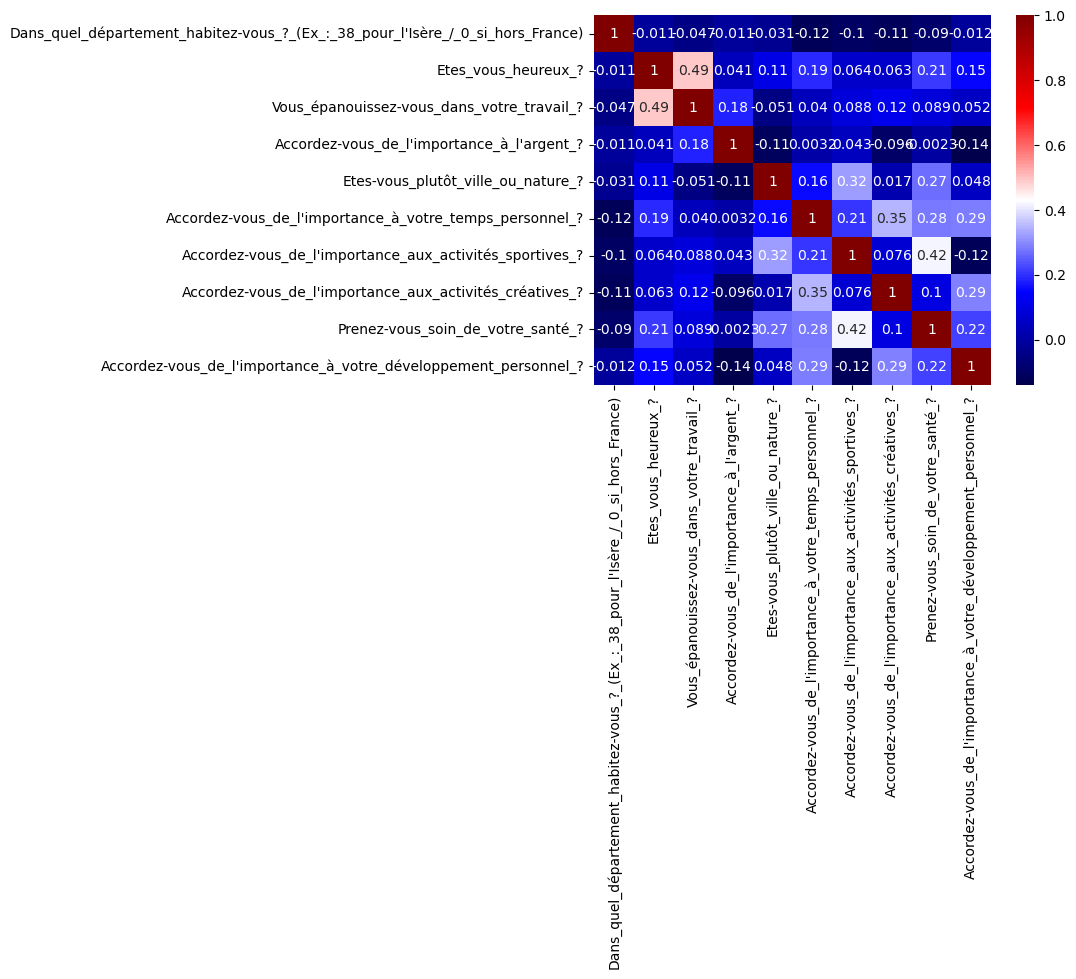

In [16]:
cor = dfb[dfb["Quel_est_votre_sexe_?"]=="Homme"][col_quant].corr(method="spearman")
sns.heatmap(cor,annot=True,cmap="seismic")

### Travail

<Axes: xlabel='Etes_vous_heureux_?', ylabel='count'>

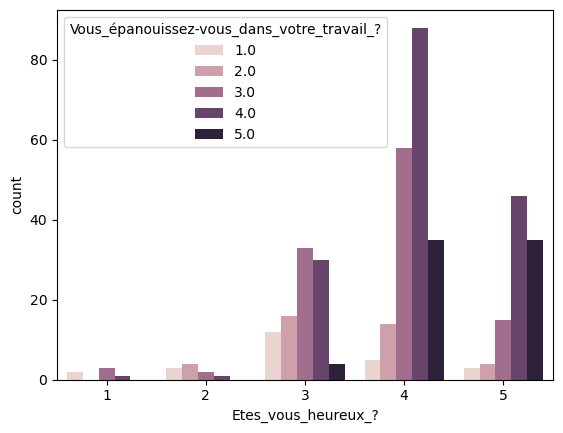

In [17]:
sns.countplot(x=dfb["Etes_vous_heureux_?"],hue=dfb["Vous_épanouissez-vous_dans_votre_travail_?"])

In [18]:
# H0 : Il n'y a pas de rellation entre l'épanouissement au travail et le bonheur
# Je choisi de traiter les valeur (1 a 5) comme des variable ordinale et de choisir un test adapté pour comparer 2 variables ordinales
dfb_drop_travail = dfb[dfb["Vous_épanouissez-vous_dans_votre_travail_?"].notna()]
stats.kendalltau(dfb_drop_travail["Etes_vous_heureux_?"],dfb_drop_travail["Vous_épanouissez-vous_dans_votre_travail_?"])

# La p-value permet de rejeter H0 et donc d'établir un relation entre ces 2 valeur

SignificanceResult(statistic=np.float64(0.3518418035275241), pvalue=np.float64(8.506700275445801e-17))

In [19]:
# Testons d'utiliser un autre test pour voir:
# Test de comparaison moyenne :
stats.ttest_ind(dfb_drop_travail["Etes_vous_heureux_?"],dfb_drop_travail["Vous_épanouissez-vous_dans_votre_travail_?"])

TtestResult(statistic=np.float64(5.700183866096016), pvalue=np.float64(1.665422265925432e-08), df=np.float64(826.0))

### Homme/femme

<Axes: xlabel='Etes_vous_heureux_?', ylabel='count'>

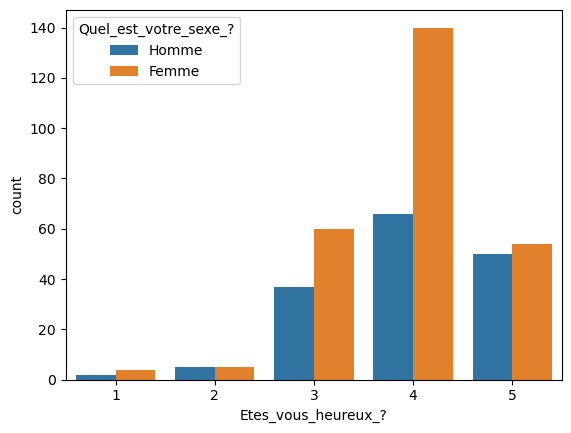

In [20]:
sns.countplot(dfb, x="Etes_vous_heureux_?", hue='Quel_est_votre_sexe_?')

In [21]:
# Les femme sont moin heureuse que les homme ?
print(dfb[dfb["Quel_est_votre_sexe_?"]=="Homme"]["Etes_vous_heureux_?"].mean())
print(dfb[dfb["Quel_est_votre_sexe_?"]=="Femme"]["Etes_vous_heureux_?"].mean())
#H0 : Les femme et les homme on le meme niveau de heureux
stats.ttest_ind(dfb[dfb["Quel_est_votre_sexe_?"]=="Homme"]["Etes_vous_heureux_?"],dfb[dfb["Quel_est_votre_sexe_?"]=="Femme"]["Etes_vous_heureux_?"])
#La p-values ne permet pas de rejetter H0

3.98125
3.893536121673004


TtestResult(statistic=np.float64(1.0505417403308015), pvalue=np.float64(0.2940717595772231), df=np.float64(421.0))

### Paris

In [22]:
# Les gens sont ils moins heureux a Paris ?
ile_de_france = [75,77,78,91,92,93,94,95]
print(dfb[dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes_vous_heureux_?"].mean())
print(dfb[~dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes_vous_heureux_?"].mean())
#H0 : Les gens sont aussi heureux a Paris qu'ailleur en france
stats.ttest_ind(dfb[dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes_vous_heureux_?"],dfb[~dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes_vous_heureux_?"])

# La p-value ne permet pas de réfuter H0

3.9583333333333335
3.92022792022792


TtestResult(statistic=np.float64(0.3532722102721797), pvalue=np.float64(0.7240612006836556), df=np.float64(421.0))

In [23]:
# Les parisient n'aime pas la nature ?
print(dfb[dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes-vous_plutôt_ville_ou_nature_?"].mean())
print(dfb[~dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes-vous_plutôt_ville_ou_nature_?"].mean())
#H0 : Les gens en région Parisienne aiment auttant ou plus la nature qu'ailleur en france
stats.ttest_ind(dfb[dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes-vous_plutôt_ville_ou_nature_?"],dfb[~dfb["Dans_quel_département_habitez-vous_?_(Ex_:_38_pour_l\'Isère_/_0_si_hors_France)"].isin(ile_de_france)]["Etes-vous_plutôt_ville_ou_nature_?"],alternative="less")
# On peut donc rejetter H0
# On peu donc dire qu'en région parisienne les gens ont plus tendance a préférer la ville qu'ailleur en france

3.2777777777777777
3.7777777777777777


TtestResult(statistic=np.float64(-3.500700571356022), pvalue=np.float64(0.0002568005966243518), df=np.float64(421.0))

### Famille / Amis

In [24]:
print(dfb[~dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Votre famille')]["Etes_vous_heureux_?"].mean())
print(dfb[dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Votre famille')]["Etes_vous_heureux_?"].mean())
#H0 les gens qui n'accorde pas d'importance à leur famille sont auttant/plus heureux que les autres
print(stats.ttest_ind(dfb[~dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Votre famille')]["Etes_vous_heureux_?"],dfb[dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Votre famille')]["Etes_vous_heureux_?"],alternative="less"))

print("On peut donc dire en étant sur a 95.5% que les gens qui accorde de l'importance à leur famille sont plus heureux que ceux qui n'en accorde pas")

3.74
3.9517426273458445
TtestResult(statistic=np.float64(-1.6918337994017287), pvalue=np.float64(0.045708816543664696), df=np.float64(421.0))
On peut donc dire en étant sur a 95.5% que les gens qui accorde de l'importance à leur famille sont plus heureux que ceux qui n'en accorde pas


In [25]:
print(dfb[~dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Vos amis')]["Etes_vous_heureux_?"].mean())
print(dfb[dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Vos amis')]["Etes_vous_heureux_?"].mean())
#H0 les gens qui n'accorde pas d'importance à leur amis sont auttant/plus heureux que les autres
print(stats.ttest_ind(dfb[~dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Vos amis')]["Etes_vous_heureux_?"],dfb[dfb["Accordez-vous_de_l'importance_à_..._?_(Cochez_si_oui)"].str.contains('Vos amis')]["Etes_vous_heureux_?"],alternative="less"))

print("On peut donc dire en étant sur a 98.2% que les gens qui accorde de l'importance à leur amis sont plus heureux")

3.721311475409836
3.9613259668508287
TtestResult(statistic=np.float64(-2.0904397225067353), pvalue=np.float64(0.018588787836219554), df=np.float64(421.0))
On peut donc dire en étant sur a 98.2% que les gens qui accorde de l'importance à leur amis sont plus heureux


### Age

In [91]:
dfb['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)'].hist()

On remarque que l'histogramme n'a pas la forme classique d'un histogramme d'age de population général, cela mets donc en évidence qu'il y a un biais d'échantillonage , et les résultat observé sont a relativisé et les valeur de p-values sont relativement faussé.

In [100]:
# Définir les bornes des tranches
bins = [0, 19, 24, 29, 34, 39, 44, 49, 54 , 59, 64, 69, 74, 100]
labels = ['15-19', '20-24', '25-30', '30-34', '35-39','40-44','45-49','50-54,','55-60','60-64','65-69','70-74','75+']

dfb['tranche_age'] = pd.cut(dfb['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)'], bins=bins, labels=labels, right=False)


dfb.groupby(['tranche_age'],observed=True)['Etes_vous_heureux_?'].mean().plot(kind='bar')

In [101]:
pop_insee = [4300,3935,3996,4067,4358,4375,4246,4460,4432,4346,3992,3661,7681]
s_popi = pd.Series(pop_insee, index= labels)
s_popi.plot(kind='bar')

In [106]:
dfb.groupby('tranche_age',observed=False)['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)'].count().plot(kind='bar')

In [107]:
# H0 : les deux distributions sont idendentique:
stats.mannwhitneyu(pop_insee,dfb.groupby('tranche_age',observed=False)['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)'].count())

# On peut donc rejetter H0 et donc dore que la distribution de l'échantillons est différente de la distribution réelle de la pop francaise

MannwhitneyuResult(statistic=np.float64(169.0), pvalue=np.float64(1.6441834719135152e-05))

In [41]:
print(dfb[dfb['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)']<30]['Etes_vous_heureux_?'].mean())
print(dfb[dfb['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)']>=30]['Etes_vous_heureux_?'].mean())

#H0 Les gens de moins de 30 ans sont auttant heureux que ceux de 30 ou +:
stats.ttest_ind(dfb[dfb['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)']<30]['Etes_vous_heureux_?'],dfb[dfb['Quel_est_votre_âge_?_(Ex_:_30_pour_30_ans)']>=30]['Etes_vous_heureux_?'])

# On peut donc rejetter H0 avec 99,3% de certitude

3.8011049723756907
4.020661157024794


TtestResult(statistic=np.float64(-2.7025021726352394), pvalue=np.float64(0.0071603084387483135), df=np.float64(421.0))

## COMPETENCE - Réaliser une mini infographie d'une demie page avec au moins 5 informations intéressantes découvertes (dont au moins 2 tests d'hypothèses) dans ce jeu de données

#  Sujet 3 (bonus) : Application mobile : jeu Cookie Cats

Les données sont issues de Kaggle : https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing

Les tests statistiques sont également utilisés dans le test de nouvelles fonctionnalités (application, site web,...), afin de voir si mettre un bouton en turquoise attire plus qu'un bouton en fushia par exemple.

Ressources :
- https://fr.wikipedia.org/wiki/Test_A/B
- 🌞 https://www.youtube.com/watch?v=BmNBxAhatYI

Importez les données :

In [44]:
df = pd.read_csv("./Data/cookie_cats.csv",sep=",")
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


Regardez globalement ce qu'il y a dedans :

In [51]:
df.sort_values("sum_gamerounds",ascending=False)
df.drop(57702,inplace= True)

Nous avons ici plusieurs informations :
- userid : identifiant de l'utilisateur
- version : les deux versions de l'application à comparer
- les indicateurs de performance de l'application :
    - sum_gamerounds : le nombre de tours de jeu joués par le joueur au cours des 14 premiers jours suivant l'installation
    - retention_1 : est-ce que le joueur est revenu et a joué 1 jour après l'installation ?
    - retention_7 : est-ce que le joueur est revenu et a joué 7 jours après l'installation ?

L'idée ici va être de regarder quelle version de l'application permet une meilleure performance de cette dernière en moyenne.

Commençons par créer les deux groupes à comparer :

In [71]:
dfa = df[df["version"]=="gate_30"]
dfa = dfa[dfa["sum_gamerounds"]!=0]  # les joueur qui ont fait 0 partie ne nous interesse pas
dfb = df[df["version"]=="gate_40"]
dfb = dfb[dfb["sum_gamerounds"]!=0]

## En terme de nombre de tours joués par le joueur au cours des 14 premiers jours, quelle version est la meilleure ?

In [75]:
dfa["sum_gamerounds"].mean()

np.float64(53.66776577335017)

In [73]:
dfb["sum_gamerounds"].mean()

np.float64(53.728356971818016)

In [76]:
stats.ttest_ind(dfa["sum_gamerounds"],dfb["sum_gamerounds"])

TtestResult(statistic=np.float64(-0.0851720765870841), pvalue=np.float64(0.932124787372842), df=np.float64(86192.0))

## Par rapport aux joueurs qui reviennent 1 jour après l'installation, quelle version est la meilleure ?

In [58]:
dfa["retention_1"].sum()

np.int64(20034)

In [59]:
dfb["retention_1"].sum()

np.int64(20119)

In [79]:
count = [dfa["retention_1"].sum() , dfb["retention_1"].sum()]
print(count)
nobs = [dfa["retention_1"].count() , dfb["retention_1"].count()]
print(nobs)
stat, pval = proportions_ztest(count,nobs,alternative='larger')
print(pval)


[np.int64(19993), np.int64(20073)]
[np.int64(42762), np.int64(43432)]
0.056986045716649385


## Par rapport aux joueurs qui reviennent 7 jours après l'installation, quelle version est la meilleure ?

In [60]:
dfa["retention_7"].sum()

np.int64(8501)

In [61]:
dfb["retention_7"].sum()

np.int64(8279)

In [80]:
count = [dfa["retention_7"].sum() , dfb["retention_7"].sum()]
print(count)
nobs = [dfa["retention_7"].count() , dfb["retention_7"].count()]
print(nobs)
stat, pval = proportions_ztest(count,nobs,alternative='larger')
print(pval)

[np.int64(8485), np.int64(8266)]
[np.int64(42762), np.int64(43432)]
0.0013231668548868666


## Quelle version devrait choisir l'éditeur selon vous ?

In [ ]:
# Le resultat sur lequelle on a une p-value inférieur a 0.05 est la retention a 7 jours, l'éditeur devrai donc choisir la version B soit : gate 40